# 05 — Portfolio loss and the tail

Notebook 04 produced a probability of default for every loan. A lender does not
hold one loan, so the question that actually matters is what happens to the
**book**: not "how likely is this borrower to fail" but "how much could this
portfolio lose, and how bad does bad get?"

That reframing is the entire subject of catastrophe risk and ILS, and the
machinery is the same object under a different name:

| Credit portfolio | Catastrophe / ILS |
|---|---|
| Expected loss on the book | **AAL** — average annual loss |
| Distribution of portfolio loss | The loss distribution behind an **EP curve** |
| P(loss > X) | **Exceedance probability** |
| 1-in-100 portfolio loss | 100-year return period loss |
| Loss above expected | **Unexpected loss** — what capital is held against |
| Systematic factor driving correlated defaults | The event — one hurricane hitting many policies |

The last row is the one that matters most, and this notebook is built around
demonstrating it: **a portfolio of 330,000 loans has a meaningful tail only
because the loans are correlated.** Take the correlation away and the tail
disappears. That is exactly why a cat portfolio is dangerous and a portfolio of
330,000 independent coin flips is not.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from src import data_prep as dp  # noqa: E402
from src import plotting as pl  # noqa: E402

pl.set_style()
rng = np.random.default_rng(42)

book = pd.read_parquet(dp.PROCESSED.parent / "scored_test.parquet")
print(f"Portfolio: {len(book):,} loans, 2015–2016 vintages")
print(f"Exposure:  ${book['funded_amnt'].sum()/1e9:.2f}B funded principal")

Portfolio: 333,721 loans, 2015–2016 vintages
Exposure:  $4.32B funded principal


## Step 1 — Expected loss (the AAL analog)

Expected loss on a credit book is the standard three-term product, computed
loan by loan and summed:

$$EL \;=\; \sum_i PD_i \times LGD \times EAD_i$$

* **PD** — probability of default, from notebook 04
* **LGD** — loss given default: the share of exposure actually lost when a loan
  fails. Notebook 03 measured this at roughly 52%, and — importantly — showed it
  is *stable*, moving only about 1.5× across the whole grade scale while
  frequency moves 7×. That stability is what justifies treating LGD as a
  constant here rather than modeling it. If severity were the volatile term, as
  it is in property catastrophe, this simplification would be indefensible.
* **EAD** — exposure at default. Funded principal, which is conservative: a loan
  that fails in month 20 has already amortised some principal away.

One calibration adjustment. Notebook 04 showed the model under-predicts on this
book by about 12% in relative terms, because the 2015–2016 vintages were worse
than the training period. Carrying that bias into a loss forecast would
understate the answer, so we scale the PDs to match the observed default rate
before aggregating. **This is the recalibration step that notebook 04 argued
for, applied.**

In [2]:
LGD = 0.52  # portfolio-average loss given default, measured in notebook 01

calibration_factor = book["charged_off"].mean() / book["pd_pred"].mean()
book["pd_cal"] = np.clip(book["pd_pred"] * calibration_factor, 1e-6, 0.999)

print(f"Raw model mean PD:        {book['pd_pred'].mean():.3%}")
print(f"Observed default rate:    {book['charged_off'].mean():.3%}")
print(f"Calibration factor:       ×{calibration_factor:.4f}")
print(f"Calibrated mean PD:       {book['pd_cal'].mean():.3%}")

exposure = book["funded_amnt"].values
pd_i = book["pd_cal"].values

expected_loss = float((pd_i * LGD * exposure).sum())
total_exposure = float(exposure.sum())

print()
print(f"Total exposure (EAD):     ${total_exposure/1e9:.3f}B")
print(f"Expected loss (the AAL):  ${expected_loss/1e6:,.1f}M")
print(f"Expected loss rate:       {expected_loss/total_exposure:.2%} of exposure")
print()
print(f"Actual realised net loss: ${book['net_chargeoff'].sum()/1e6:,.1f}M "
      f"({book['net_chargeoff'].sum()/total_exposure:.2%})")

Raw model mean PD:        13.256%
Observed default rate:    14.879%
Calibration factor:       ×1.1225
Calibrated mean PD:       14.879%

Total exposure (EAD):     $4.320B
Expected loss (the AAL):  $322.4M
Expected loss rate:       7.46% of exposure

Actual realised net loss: $322.0M (7.45%)


The modeled expected loss lands close to what the book actually lost, which is
the minimum bar for taking the rest of this seriously.

**But a point estimate is not a risk model.** Expected loss tells you what to
charge; it tells you nothing about what to hold capital against. For that you
need the distribution.

## Step 2 — Two simulations, and why the difference is the whole point

### Simulation A: independent defaults

Each loan defaults on its own coin flip, with its own probability, independent
of every other loan. This is the naive model, and it is instructive precisely
because it is wrong.

### Simulation B: one systematic factor (the Vasicek / ASRF model)

The standard credit portfolio model, and the one sitting underneath the Basel
capital formula. Every borrower's creditworthiness has a common component — the
economy — and an idiosyncratic component:

$$A_i = \sqrt{\rho}\, Z + \sqrt{1-\rho}\, \varepsilon_i$$

where $Z$ is the systematic factor shared by all borrowers, $\varepsilon_i$ is
borrower-specific, and $\rho$ is the asset correlation. A loan defaults when
$A_i$ crosses its threshold, which gives a conditional default probability:

$$PD_i(Z) \;=\; \Phi\!\left(\frac{\Phi^{-1}(PD_i) + \sqrt{\rho}\,Z}{\sqrt{1-\rho}}\right)$$

In plain English: **in a bad year, everybody's default probability rises at
once.** $Z$ is the event. It is the credit-portfolio equivalent of the hurricane
that damages ten thousand houses on the same afternoon — which is why a cat book
and a credit book both have tails, and a bag of independent coin flips does not.

For $\rho$ we use the **Basel "other retail" supervisory formula**, a
PD-dependent correlation rather than a number we picked:

$$\rho(PD) = 0.03 \cdot \frac{1 - e^{-35\,PD}}{1 - e^{-35}} + 0.16 \cdot \left(1 - \frac{1 - e^{-35\,PD}}{1 - e^{-35}}\right)$$

In [3]:
def basel_retail_correlation(pd_value: np.ndarray | float) -> np.ndarray | float:
    """
    Basel II/III supervisory asset correlation for 'other retail' exposures.

    Regulatory rather than estimated, and that is deliberate: it is a published,
    citable anchor, which is a better starting point than a number chosen to make
    the output look reasonable. The sensitivity analysis at the end of this
    notebook shows how much the answer depends on it.
    """
    k = (1 - np.exp(-35 * pd_value)) / (1 - np.exp(-35))
    return 0.03 * k + 0.16 * (1 - k)


RHO = float(basel_retail_correlation(book["pd_cal"].mean()))
print(f"Portfolio mean PD:  {book['pd_cal'].mean():.2%}")
print(f"Basel asset correlation implied: rho = {RHO:.4f}")

Portfolio mean PD:  14.88%
Basel asset correlation implied: rho = 0.0307


### Making the simulation tractable

Drawing 333,721 independent Bernoullis across 20,000 scenarios is 6.7 billion
random numbers. It is also unnecessary: loans with the same PD and similar size
are exchangeable, so we bucket the book and draw a **binomial count** per bucket
instead. Identical distribution, three orders of magnitude less work.

We stratify on PD (100 buckets) *and* loan size (4 buckets), because exposure
concentration matters for the tail — losing 100 large loans is not the same as
losing 100 average ones.

In [4]:
book["pd_bucket"] = pd.qcut(book["pd_cal"], 100, labels=False, duplicates="drop")
book["size_bucket"] = pd.qcut(book["funded_amnt"], 4, labels=False, duplicates="drop")

buckets = book.groupby(["pd_bucket", "size_bucket"], observed=True).agg(
    n=("pd_cal", "size"),
    pd_mean=("pd_cal", "mean"),
    ead_mean=("funded_amnt", "mean"),
)
buckets = buckets[buckets["n"] > 0]

n_b = buckets["n"].values.astype(np.int64)
pd_b = buckets["pd_mean"].values
ead_b = buckets["ead_mean"].values

print(f"{len(buckets)} buckets covering {n_b.sum():,} loans")
print(f"Bucket exposure check: ${(n_b * ead_b).sum()/1e9:.3f}B "
      f"vs actual ${total_exposure/1e9:.3f}B")

400 buckets covering 333,721 loans
Bucket exposure check: $4.320B vs actual $4.320B


In [5]:
N_SCENARIOS = 20_000

# --- Simulation A: independent defaults -------------------------------------- #
defaults_indep = rng.binomial(n_b, pd_b, size=(N_SCENARIOS, len(n_b)))
loss_indep = (defaults_indep * ead_b * LGD).sum(axis=1)

# --- Simulation B: one systematic factor ------------------------------------- #
z = rng.standard_normal(N_SCENARIOS)  # the "event" -- higher Z means a worse year
threshold = norm.ppf(pd_b)
pd_conditional = norm.cdf(
    (threshold[None, :] + np.sqrt(RHO) * z[:, None]) / np.sqrt(1 - RHO)
)
defaults_corr = rng.binomial(np.broadcast_to(n_b, pd_conditional.shape), pd_conditional)
loss_corr = (defaults_corr * ead_b * LGD).sum(axis=1)

results = pd.DataFrame(
    {
        "Independent defaults": loss_indep,
        f"Correlated (rho={RHO:.3f})": loss_corr,
    }
)

summary = pd.DataFrame(
    {
        "Mean loss ($M)": (results.mean() / 1e6).round(2),
        "Std dev ($M)": (results.std() / 1e6).round(2),
        "Coefficient of variation": (results.std() / results.mean()).map("{:.2%}".format),
        "95th pct ($M)": (results.quantile(0.95) / 1e6).round(2),
        "99th pct ($M)": (results.quantile(0.99) / 1e6).round(2),
        "99.6th pct ($M)": (results.quantile(0.996) / 1e6).round(2),
        "99th pct as x mean": (results.quantile(0.99) / results.mean()).round(2),
    }
)
summary.T

,Independent defaults,Correlated (rho=0.031)
Mean loss ($M),322.45,322.46
Std dev ($M),1.53,86.4
Coefficient of variation,0.47%,26.79%
95th pct ($M),324.98,476.85
99th pct ($M),325.95,558.28
99.6th pct ($M),326.42,596.89
99th pct as x mean,1.01,1.73


## Step 3 — The loss distribution

Both simulations have the same mean. They are not remotely the same risk.

/tmp/ipykernel_3099/4250160971.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.92])


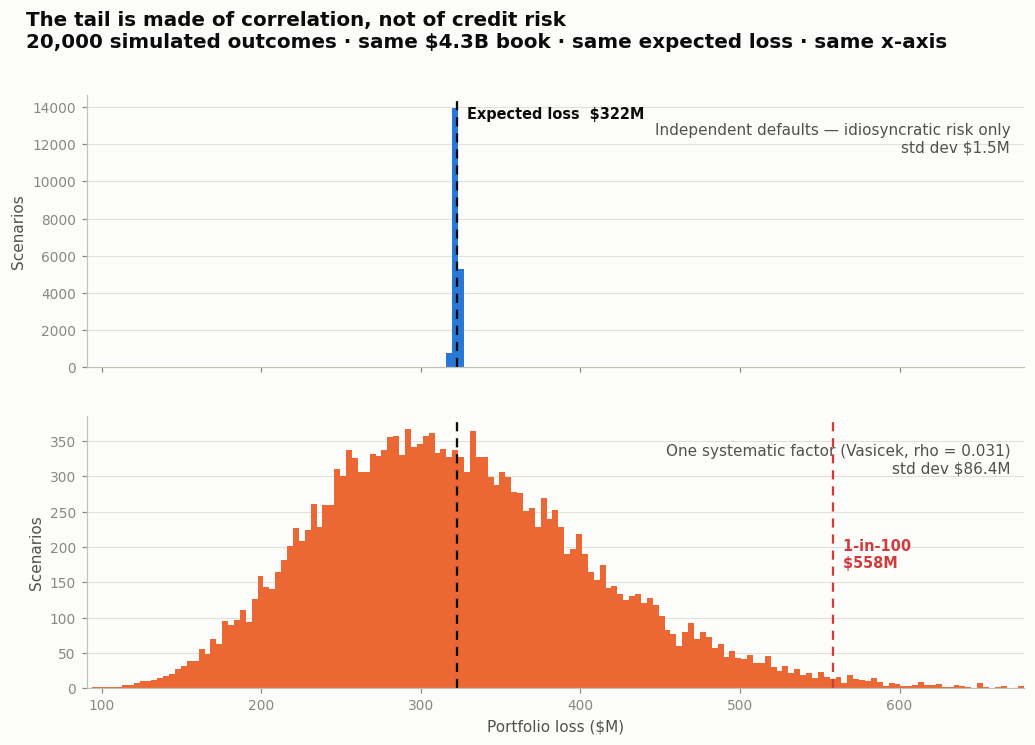

In [6]:
el_m = expected_loss / 1e6
p99 = np.percentile(loss_corr, 99) / 1e6

# Two panels sharing one x-axis rather than one overlay. The independent
# distribution is ~55x narrower than the correlated one; overlaid on a shared
# y-scale it becomes a single spike and the correlated shape flattens into the
# floor. Stacking preserves both shapes while keeping the comparison honest --
# the x-axis, which is the thing being compared, is identical.
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                         gridspec_kw={"hspace": 0.18})

x_lo = min(loss_indep.min(), loss_corr.min()) / 1e6 * 0.96
x_hi = np.percentile(loss_corr, 99.9) / 1e6 * 1.04
bins = np.linspace(x_lo, x_hi, 160)

panels = [
    (axes[0], loss_indep, pl.CATEGORICAL[0],
     "Independent defaults — idiosyncratic risk only",
     f"std dev ${loss_indep.std()/1e6:.1f}M"),
    (axes[1], loss_corr, pl.CATEGORICAL[1],
     f"One systematic factor (Vasicek, rho = {RHO:.3f})",
     f"std dev ${loss_corr.std()/1e6:.1f}M"),
]

for ax, losses, color, label, sd in panels:
    ax.hist(losses / 1e6, bins=bins, color=color)
    ax.axvline(el_m, color=pl.INK_PRIMARY, linewidth=1.5, linestyle=(0, (4, 3)))
    ax.set_ylabel("Scenarios")
    ax.text(0.985, 0.90, f"{label}\n{sd}", transform=ax.transAxes,
            ha="right", va="top", fontsize=10, color=pl.INK_SECONDARY)
    pl.style_axes(ax)

axes[0].text(el_m, axes[0].get_ylim()[1] * 0.96, f"  Expected loss  ${el_m:,.0f}M",
             fontsize=9.5, color=pl.INK_PRIMARY, va="top", fontweight="semibold")

axes[1].axvline(p99, color=pl.STATUS_CRITICAL, linewidth=1.5, linestyle=(0, (4, 3)))
axes[1].text(p99, axes[1].get_ylim()[1] * 0.55, f"  1-in-100\n  ${p99:,.0f}M",
             fontsize=9.5, color=pl.STATUS_CRITICAL, va="top", fontweight="semibold")

axes[1].set_xlabel("Portfolio loss ($M)")
axes[0].set_xlim(x_lo, x_hi)

fig.suptitle(
    "The tail is made of correlation, not of credit risk\n"
    "20,000 simulated outcomes · same $4.3B book · same expected loss · same x-axis",
    x=0.075, ha="left", fontsize=13, fontweight="semibold", color=pl.INK_PRIMARY,
    y=0.99,
)
fig.tight_layout(rect=[0, 0, 1, 0.92])

pl.save_fig(fig, "05_loss_distribution.png")
plt.show()

**This chart is the argument.**

The blue distribution is what a portfolio of 333,721 *independent* loans looks
like: a spike. Individual credit risk diversifies away almost completely — with
a book this large, the law of large numbers does its job and the realised loss
is the expected loss, give or take a rounding error. If defaults were truly
independent, a lender would need essentially no capital against this book.

The orange distribution is the same book with a single systematic factor. Same
expected loss, a completely different risk profile: a long right tail where a bad
economy pushes everyone's default probability up together.

**Diversification does not protect against a common factor.** That sentence is
equally at home in a credit committee and a reinsurance underwriting meeting. It
is why writing more Florida wind does not diversify a Florida wind portfolio, and
it is why the 2008 mortgage models — which assumed low correlation — failed the
way they did. The whole reason a portfolio needs capital is the correlation
term.

## Step 4 — The EP curve

Invert the distribution and you get the form a cat modeler or an ILS investor
reads directly: for each loss level, the probability of exceeding it.

The vertical axis is exceedance probability; the right-hand labels convert it to
the return period an insurance audience thinks in — a 1% exceedance probability
is the "1-in-100."

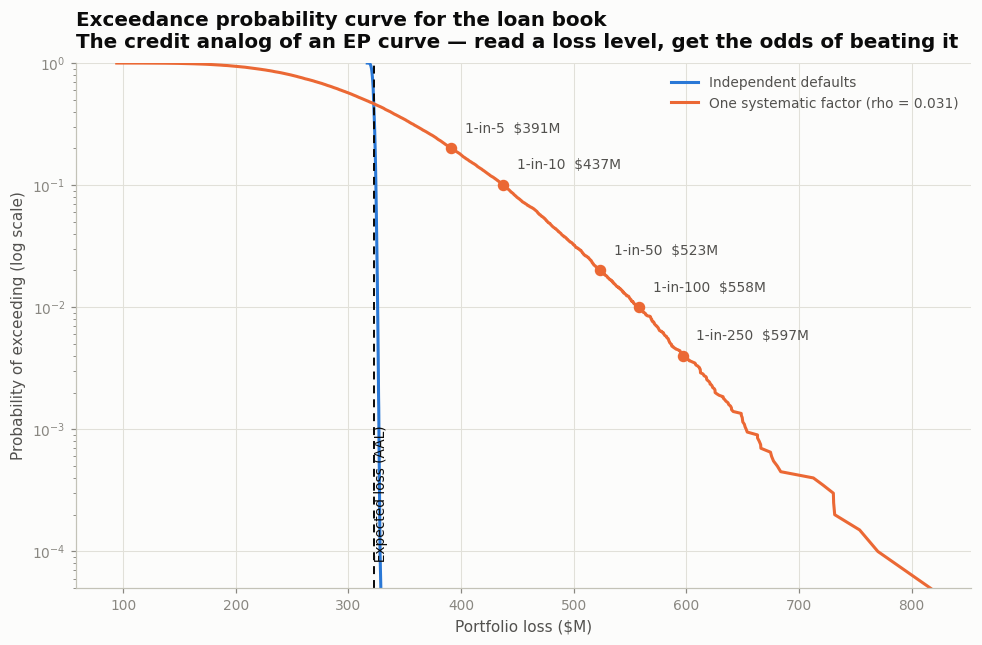

In [7]:
sorted_loss = np.sort(loss_corr)[::-1]
exceed_prob = np.arange(1, len(sorted_loss) + 1) / len(sorted_loss)

sorted_indep = np.sort(loss_indep)[::-1]

fig, ax = plt.subplots(figsize=(10.5, 6.2))

ax.plot(sorted_indep / 1e6, exceed_prob, color=pl.CATEGORICAL[0],
        label="Independent defaults")
ax.plot(sorted_loss / 1e6, exceed_prob, color=pl.CATEGORICAL[1],
        label=f"One systematic factor (rho = {RHO:.3f})")

ax.axvline(el_m, color=pl.INK_PRIMARY, linewidth=1.3, linestyle=(0, (4, 3)))
ax.text(el_m, 1.4 / N_SCENARIOS, "  Expected loss (AAL)", rotation=90, fontsize=9,
        color=pl.INK_PRIMARY, va="bottom")

for prob, label in [(0.20, "1-in-5"), (0.10, "1-in-10"), (0.02, "1-in-50"),
                    (0.01, "1-in-100"), (0.004, "1-in-250")]:
    loss_at = np.percentile(loss_corr, 100 * (1 - prob)) / 1e6
    ax.plot([loss_at], [prob], marker="o", markersize=6.5,
            color=pl.CATEGORICAL[1], zorder=5)
    ax.annotate(f"{label}  ${loss_at:,.0f}M", xy=(loss_at, prob),
                xytext=(loss_at + 12, prob * 1.35),
                fontsize=9, color=pl.INK_SECONDARY)

ax.set_yscale("log")
ax.set_ylim(1 / N_SCENARIOS, 1)
ax.set_xlabel("Portfolio loss ($M)")
ax.set_ylabel("Probability of exceeding (log scale)")
ax.set_title(
    "Exceedance probability curve for the loan book\n"
    "The credit analog of an EP curve — read a loss level, get the odds of beating it",
    loc="left",
)
pl.style_axes(ax, xgrid=True, ygrid=True)
ax.legend(loc="upper right")

pl.save_fig(fig, "05_ep_curve.png")
plt.show()

## Step 5 — Return periods and what capital is for

The table an ILS investor or a credit-risk officer would actually price off.

In [8]:
return_periods = [2, 5, 10, 20, 50, 100, 250]
rows = []
for rp in return_periods:
    q = 1 - 1 / rp
    loss_rp = float(np.percentile(loss_corr, 100 * q))
    rows.append(
        {
            "Return period": f"1-in-{rp}",
            "Exceedance prob": f"{1/rp:.1%}",
            "Portfolio loss ($M)": round(loss_rp / 1e6, 1),
            "Loss rate": f"{loss_rp/total_exposure:.2%}",
            "× expected loss": round(loss_rp / expected_loss, 2),
            "Unexpected loss ($M)": round((loss_rp - expected_loss) / 1e6, 1),
        }
    )
rp_table = pd.DataFrame(rows).set_index("Return period")
rp_table

,Exceedance prob,Portfolio loss ($M),Loss rate,× expected loss,Unexpected loss ($M)
Return period,,,,,
1-in-2,50.0%,314.5,7.28%,0.98,-7.9
1-in-5,20.0%,391.3,9.06%,1.21,68.9
1-in-10,10.0%,437.3,10.12%,1.36,114.9
1-in-20,5.0%,476.9,11.04%,1.48,154.4
1-in-50,2.0%,523.4,12.12%,1.62,201.0
1-in-100,1.0%,558.3,12.92%,1.73,235.8
1-in-250,0.4%,596.9,13.82%,1.85,274.5


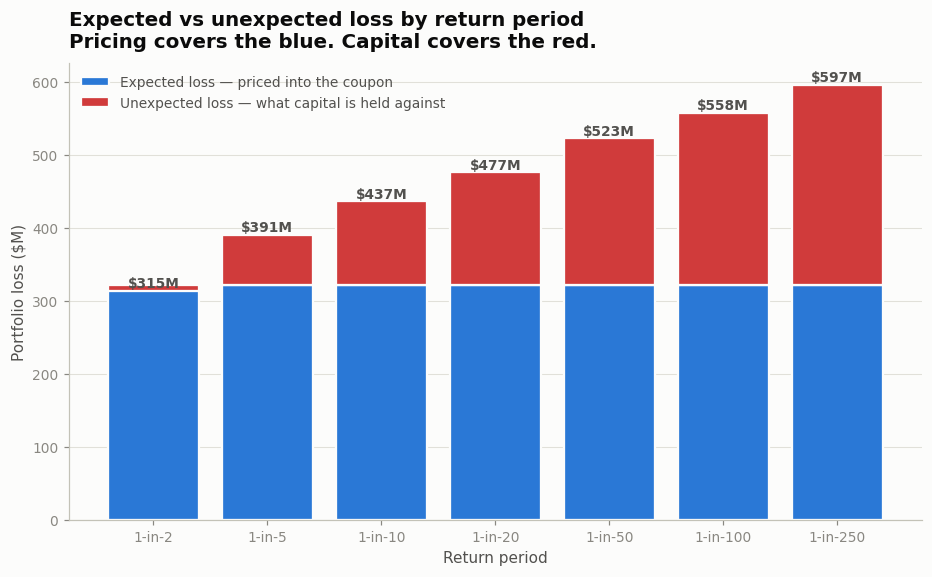

In [9]:
fig, ax = plt.subplots(figsize=(10, 5.4))

x = np.arange(len(rp_table))
el_bar = np.full(len(rp_table), expected_loss / 1e6)
ul_bar = rp_table["Unexpected loss ($M)"].values

ax.bar(x, el_bar, color=pl.CATEGORICAL[0], label="Expected loss — priced into the coupon",
       edgecolor=pl.SURFACE, linewidth=1.5)
ax.bar(x, ul_bar, bottom=el_bar, color=pl.STATUS_CRITICAL,
       label="Unexpected loss — what capital is held against",
       edgecolor=pl.SURFACE, linewidth=1.5)

for xi, (e, u) in enumerate(zip(el_bar, ul_bar)):
    ax.text(xi, e + u + 4, f"${e+u:,.0f}M", ha="center", fontsize=9,
            color=pl.INK_SECONDARY, fontweight="semibold")

ax.set_xticks(x)
ax.set_xticklabels(rp_table.index)
ax.set_xlabel("Return period")
ax.set_ylabel("Portfolio loss ($M)")
ax.set_title(
    "Expected vs unexpected loss by return period\n"
    "Pricing covers the blue. Capital covers the red.",
    loc="left",
)
pl.style_axes(ax)
ax.legend(loc="upper left")

pl.save_fig(fig, "05_capital_view.png")
plt.show()

The split is the point. **Expected loss is a cost of doing business and belongs
in the price.** Unexpected loss — everything above the mean out to the chosen
return period — is what equity is held against, and it is the number that decides
whether the spread computed back in notebook 03 is actually an adequate return.

This is identical in structure to how a reinsurer thinks about a treaty: the
expected loss cost goes into the technical rate, and the capital charge is driven
by the volatility around it. Two treaties with the same expected loss and
different tails are not the same trade, and neither are two loan books.

## Step 6 — How much does the correlation assumption drive this?

The honest question about any tail estimate: what is it actually sensitive to?
Here the answer is almost entirely $\rho$, so we should show that rather than
present one curve as though it were a measurement.

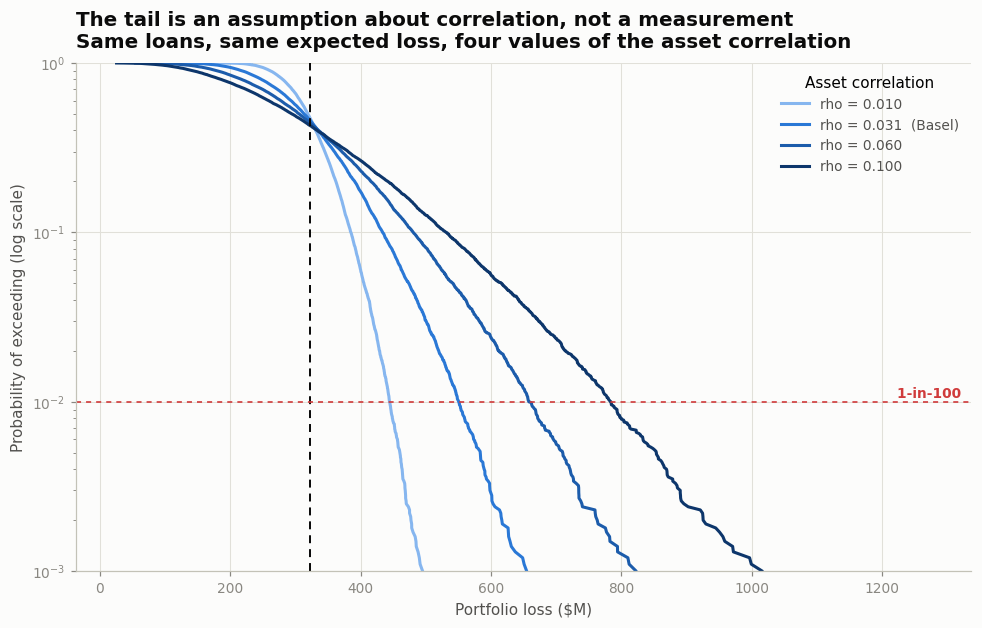

In [10]:
def simulate_tail(rho: float, n_scenarios: int = 10_000, seed: int = 7) -> np.ndarray:
    """Re-run the systematic-factor simulation at a different asset correlation."""
    r = np.random.default_rng(seed)
    z_ = r.standard_normal(n_scenarios)
    cond = norm.cdf((threshold[None, :] + np.sqrt(rho) * z_[:, None]) / np.sqrt(1 - rho))
    d = r.binomial(np.broadcast_to(n_b, cond.shape), cond)
    return (d * ead_b * LGD).sum(axis=1)


rho_grid = [0.01, RHO, 0.06, 0.10]
tails = {r_: simulate_tail(r_) for r_ in rho_grid}

fig, ax = plt.subplots(figsize=(10.5, 6))
colors = pl.ordinal_colors(len(rho_grid))

for (r_, losses), color in zip(tails.items(), colors):
    s = np.sort(losses)[::-1]
    ep = np.arange(1, len(s) + 1) / len(s)
    label = f"rho = {r_:.3f}" + ("  (Basel)" if abs(r_ - RHO) < 1e-9 else "")
    ax.plot(s / 1e6, ep, color=color, label=label)

ax.axvline(el_m, color=pl.INK_PRIMARY, linewidth=1.3, linestyle=(0, (4, 3)))
ax.axhline(0.01, color=pl.STATUS_CRITICAL, linewidth=1.1, linestyle=(0, (3, 3)))
ax.text(ax.get_xlim()[1], 0.0105, "1-in-100  ", ha="right", fontsize=9,
        color=pl.STATUS_CRITICAL, fontweight="semibold")

ax.set_yscale("log")
ax.set_ylim(1e-3, 1)
ax.set_xlabel("Portfolio loss ($M)")
ax.set_ylabel("Probability of exceeding (log scale)")
ax.set_title(
    "The tail is an assumption about correlation, not a measurement\n"
    "Same loans, same expected loss, four values of the asset correlation",
    loc="left",
)
pl.style_axes(ax, xgrid=True, ygrid=True)
ax.legend(title="Asset correlation", loc="upper right")

pl.save_fig(fig, "05_correlation_sensitivity.png")
plt.show()

In [11]:
sens = pd.DataFrame(
    {
        "1-in-10 ($M)": {r_: np.percentile(v, 90) / 1e6 for r_, v in tails.items()},
        "1-in-100 ($M)": {r_: np.percentile(v, 99) / 1e6 for r_, v in tails.items()},
        "1-in-100 as × EL": {r_: np.percentile(v, 99) / expected_loss for r_, v in tails.items()},
    }
).round(2)
sens.index.name = "rho"
sens

,1-in-10 ($M),1-in-100 ($M),1-in-100 as × EL
rho,,,
0.010000,385.09,444.31,1.38
0.030712,434.04,550.29,1.71
0.060000,480.87,658.03,2.04
0.100000,531.20,782.73,2.43


**Moving $\rho$ from 0.01 to 0.10 lifts the 1-in-100 from 1.4× expected loss to
2.4× — a 76% increase in the capital number — while expected loss does not move
at all.** Every dollar of tail risk in this portfolio is an assumption about how
correlated the borrowers are, and none of it is visible in the expected-loss
calculation. A pricing model and a capital model can agree completely on the
mean and disagree by a factor of two on the thing that matters.

Anyone who has priced a cat treaty has had this exact argument. The AAL is the
comparatively easy number; the shape of the curve above it is where the
judgement — and the disagreement — lives.

## Step 7 — Sanity check against what actually happened

A simulation that has not been checked against reality is decoration. We have
eleven years of realised vintage outcomes from notebook 02: does the model's
implied year-to-year dispersion look anything like the dispersion actually
observed between origination cohorts?

In [12]:
panel = pd.read_parquet(dp.VINTAGE_PANEL)
panel36 = panel[(panel["term_months"] == 36) & (panel["vintage_year"].between(2012, 2015))]
observed_ultimate = dp.vintage_triangle(panel36, max_mob=36)[36].dropna()

model_rate = loss_corr / total_exposure

check = pd.DataFrame(
    {
        "Metric": [
            "Mean loss rate",
            "Best case",
            "Worst case",
            "Worst / best",
            "Coefficient of variation",
        ],
        "Observed vintages (2012–2015)": [
            f"{observed_ultimate.mean():.2%}",
            f"{observed_ultimate.min():.2%}  ({observed_ultimate.idxmin()})",
            f"{observed_ultimate.max():.2%}  ({observed_ultimate.idxmax()})",
            f"{observed_ultimate.max()/observed_ultimate.min():.2f}×",
            f"{observed_ultimate.std()/observed_ultimate.mean():.1%}",
        ],
        "Simulated (rho = Basel)": [
            f"{model_rate.mean():.2%}",
            f"{np.percentile(model_rate, 12.5):.2%}  (1-in-8 good)",
            f"{np.percentile(model_rate, 87.5):.2%}  (1-in-8 bad)",
            f"{np.percentile(model_rate, 87.5)/np.percentile(model_rate, 12.5):.2f}×",
            f"{model_rate.std()/model_rate.mean():.1%}",
        ],
    }
).set_index("Metric")
check

,Observed vintages (2012–2015),Simulated (rho = Basel)
Metric,,
Mean loss rate,6.66%,7.46%
Best case,5.85% (2013),5.26% (1-in-8 good)
Worst case,7.30% (2015),9.80% (1-in-8 bad)
Worst / best,1.25×,1.86×
Coefficient of variation,9.6%,26.8%


**The model is about three times more dispersed than the observed cohorts** —
a 27% coefficient of variation against 10% realised. That gap is the most
interesting output of the check, and it has two explanations that both point the
same way:

1. **The Basel correlation is a regulatory parameter, and regulatory parameters
   are set to be conservative.** It is designed to produce capital that holds up
   in a bad decade, not to reproduce the variance of a good one. Using it as a
   realistic dispersion estimate over-states volatility on purpose.
2. **Four vintages from 2012–2015 is a benign, tiny sample.** None of them
   contains a recession — **the window does not include 2008** — and four
   observations cannot estimate a standard deviation, let alone a 1-in-100.

So the honest conclusion is not "the model is too conservative" or "the data says
10%." It is that **neither number is a measurement of the tail.** The realised
dispersion is a floor built from a calm period; the Basel figure is a
deliberately prudent ceiling. The truth for a full cycle sits between them, and
the way to narrow it is to stress the book against a downturn scenario rather
than to trust either figure.

A cat modeler faces exactly this problem when the historical event set is short:
you do not conclude the hazard is mild because the last four years were quiet.

## What this section demonstrates

1. **Expected loss is the easy part.** Loan-level PDs aggregate to a portfolio
   expected loss (the AAL) that matches realised experience closely.
2. **The tail comes from correlation, not from credit quality.** 333,721
   independent loans have almost no tail. One systematic factor creates all of
   it. Diversification does not protect against a common cause — in credit or in
   catastrophe.
3. **The EP curve turns a loss distribution into a decision.** Expected loss goes
   in the price; unexpected loss out to a chosen return period sets the capital.
4. **The tail is an assumption, so it should be shown as one.** Doubling the
   asset correlation roughly doubles the 1-in-100 while leaving expected loss
   untouched, and a model built on a benign window cannot speak credibly about a
   recession year.

All four statements are true, in the same words, of a catastrophe portfolio.
That is the point of the study.

---
**Back to:** [`REPORT.md`](../REPORT.md) — the plain-English write-up of
everything in these five notebooks.